In [ ]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

In [ ]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 30

In [ ]:
!unzip /content/drive/Shareddrives/TanoSecureDigiTalentInternships/Jayson/CNNModel_Leaves_Disease_Detection/TomatoLeaves.zip

Archive:  /content/drive/Shareddrives/TanoSecureDigiTalentInternships/Jayson/CNNModel_Leaves_Disease_Detection/TomatoLeaves.zip
   creating: TomatoLeaves/Tomato_Early_blight/
  inflating: TomatoLeaves/Tomato_Early_blight/0012b9d2-2130-4a06-a834-b1f3af34f57e___RS_Erly.B 8389.JPG  
  inflating: TomatoLeaves/Tomato_Early_blight/0034a551-9512-44e5-ba6c-827f85ecc688___RS_Erly.B 9432.JPG  
  inflating: TomatoLeaves/Tomato_Early_blight/004cbe60-8ff9-4965-92df-e86694d5e9ba___RS_Erly.B 8253.JPG  
  inflating: TomatoLeaves/Tomato_Early_blight/00c5c908-fc25-4710-a109-db143da23112___RS_Erly.B 7778.JPG  
  inflating: TomatoLeaves/Tomato_Early_blight/00e7c4b2-3005-4558-9cfa-235e356cb7a8___RS_Erly.B 7844.JPG  
  inflating: TomatoLeaves/Tomato_Early_blight/0114f7b3-7f56-4bef-aa47-7a82da142d4b___RS_Erly.B 7437.JPG  
  inflating: TomatoLeaves/Tomato_Early_blight/011aa278-a39e-40b0-b6e4-2e2f835889f0___RS_Erly.B 8251.JPG  
  inflating: TomatoLeaves/Tomato_Early_blight/01861c93-ea8b-4820-aaa8-cc6003b3e75b_

In [ ]:
#use tensorflow dataset to download these images into tf.data.dataset
#load images into the tensor using this code
dataset = tf.keras.preprocessing.image_dataset_from_directory("/content/TomatoLeaves",
                                                   shuffle= True,
                                                    image_size = (IMAGE_SIZE, IMAGE_SIZE),
                                                    batch_size = BATCH_SIZE)


Found 4500 files belonging to 3 classes.


In [ ]:
class_names = dataset.class_names
class_names

['Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_healthy']

In [ ]:
len(dataset)

141

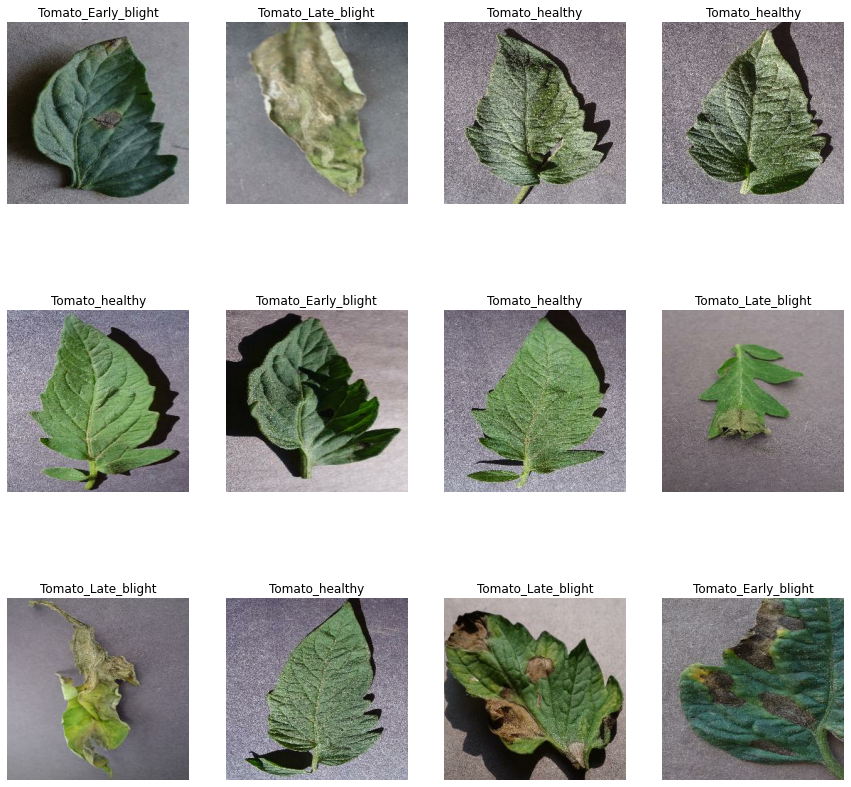

In [ ]:
plt.figure(figsize = (15,15))
for image_batch, label_batch in dataset.take(1):
     for i in range(12):
            ax =plt.subplot(3,4,i+1)
            plt.imshow(image_batch[i].numpy().astype("uint8"))
            plt.title(class_names[label_batch[i]])
            plt.axis("off")

In [ ]:
len(dataset)

141

In [ ]:
#80% ==> training
#20% ==> 10% validation, 10% test

train_size = 0.8
len(dataset)* train_size


112.80000000000001

In [ ]:
train_ds =dataset.take(112)
len(train_ds)

112

In [ ]:
test_ds = dataset.skip(112) #taking first 112 images
len(test_ds)

29

In [ ]:
val_size = 0.1 #validation size is 10%
len(dataset)* val_size


14.100000000000001

In [ ]:
val_ds = test_ds.take(14)
len(val_ds)

14

In [ ]:
test_ds = test_ds.skip(14)
len(test_ds)

15

In [ ]:
def get_dataset_partitions_tf(ds, train_split = 0.8, val_split = 0.1, test_split =0.1,shuffle = True, shuffle_size = 10000):
    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed = 12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split *ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [ ]:
train_ds, val_ds, test_ds =get_dataset_partitions_tf(dataset)

In [ ]:
len(train_ds)

112

In [ ]:
len(val_ds)

14

In [ ]:
len(test_ds)

15

In [ ]:
#now the datasets are optimize for training performance so the training will run fast
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

In [ ]:

resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE), #resizing our images into 256 * 256
    layers.experimental.preprocessing.Rescaling(1.0/255)#scale the image into 255
])

In [ ]:
#created this layer for preprocessing.
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"), #creating new samples to have a robust performance
    layers.experimental.preprocessing.RandomRotation(0.2),
])

In [ ]:
#Deep Learning Neural Network Architecture = CNN
#building the model (Convolutional neural network)
input_shape =(BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3
model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3), activation = 'relu', input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size =(3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, kernel_size =(3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation = 'relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation = 'relu'),
    layers.Dense(n_classes, activation = 'softmax'), #softmax will normalize the probability of the classes

])

model.build(input_shape =input_shape)

In [ ]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential (Sequential)      (32, 256, 256, 3)         0         
_________________________________________________________________
sequential_1 (Sequential)    (32, 256, 256, 3)         0         
_________________________________________________________________
conv2d (Conv2D)              (32, 254, 254, 32)        896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (32, 127, 127, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (32, 125, 125, 64)        18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (32, 62, 62, 64)          0         
_________________________________________________________________
conv2d_2 (Conv2D)            (32, 60, 60, 64)         

In [ ]:

model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False),
    metrics = ['Accuracy']


)

In [ ]:

history = model.fit(

    train_ds,
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    verbose =1,
    validation_data = val_ds
)

Epoch 1/30
112/112 [==============================] - 55s 183ms/step - loss: 0.9622 - Accuracy: 0.4916 - val_loss: 0.6464 - val_Accuracy: 0.6853
Epoch 2/30
112/112 [==============================] - 14s 121ms/step - loss: 0.6464 - Accuracy: 0.6988 - val_loss: 0.7602 - val_Accuracy: 0.6652
Epoch 3/30
112/112 [==============================] - 14s 121ms/step - loss: 0.4603 - Accuracy: 0.8035 - val_loss: 0.5310 - val_Accuracy: 0.7857
Epoch 4/30
112/112 [==============================] - 14s 121ms/step - loss: 0.4756 - Accuracy: 0.8038 - val_loss: 0.3326 - val_Accuracy: 0.8750
Epoch 5/30
112/112 [==============================] - 14s 121ms/step - loss: 0.3966 - Accuracy: 0.8421 - val_loss: 0.4060 - val_Accuracy: 0.8750
Epoch 6/30
112/112 [==============================] - 13s 120ms/step - loss: 0.3684 - Accuracy: 0.8393 - val_loss: 0.2947 - val_Accuracy: 0.8795
Epoch 7/30
112/112 [==============================] - 13s 120ms/step - loss: 0.3105 - Accuracy: 0.8684 - val_loss: 0.3122 - val_Ac

In [ ]:
scores =model.evaluate(test_ds)


15/15 [==============================] - 6s 46ms/step - loss: 0.0637 - Accuracy: 0.9792


In [ ]:
scores

[0.06373008340597153, 0.9791666865348816]

In [ ]:
history

In [ ]:
history.params

{'epochs': 30, 'steps': 112, 'verbose': 1}

In [ ]:
history.history.keys()

dict_keys(['loss', 'Accuracy', 'val_loss', 'val_Accuracy'])

In [ ]:
history.history['Accuracy']

[0.4916013479232788,
 0.6987681984901428,
 0.8034714460372925,
 0.8037514090538025,
 0.8421052694320679,
 0.8393056988716125,
 0.8684210777282715,
 0.8798992037773132,
 0.8972564339637756,
 0.8874580264091492,
 0.8880178928375244,
 0.9048152565956116,
 0.892497181892395,
 0.9168533086776733,
 0.8894177079200745,
 0.9252519607543945,
 0.9249719977378845,
 0.9372900128364563,
 0.9266517162322998,
 0.9440089464187622,
 0.9414893388748169,
 0.9512878060340881,
 0.9417693018913269,
 0.9591265320777893,
 0.9501679539680481,
 0.9515677690505981,
 0.9535274505615234,
 0.9554871320724487,
 0.9398096203804016,
 0.956886887550354]

In [ ]:
acc= history.history['Accuracy']
val_acc = history.history['val_Accuracy']
loss =history.history['loss']
val_loss = history.history['val_loss']

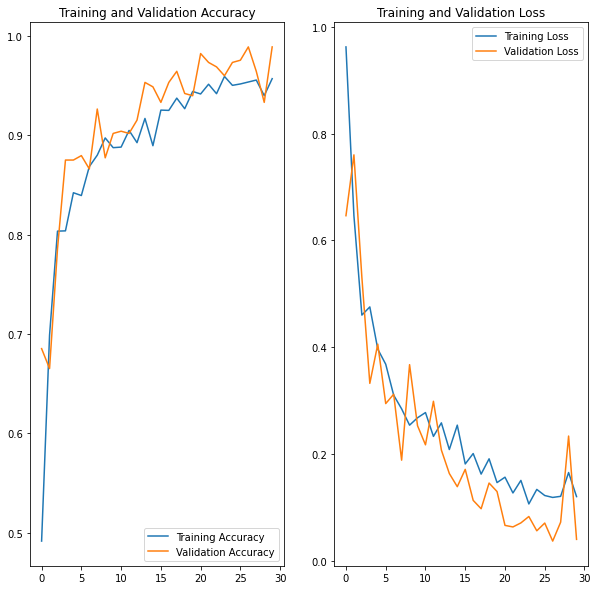

In [ ]:
plt.figure(figsize = (10,10))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label = 'Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label = 'Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss, label = 'Training Loss')
plt.plot(range(EPOCHS), val_loss, label = 'Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

First image to predict
Actual label:  Tomato_healthy
Predicted Label: Tomato_healthy


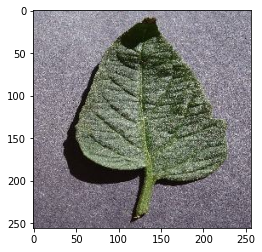

In [ ]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
  first_image = images_batch[0].numpy().astype('uint8')
  first_label = labels_batch[0].numpy()

  print('First image to predict')
  plt.imshow(first_image)
  print('Actual label: ', class_names[first_label ])

  batch_prediction =model.predict(images_batch)
  print("Predicted Label:", class_names[np.argmax(batch_prediction[0])])

In [ ]:
model.evaluate(test_ds)

15/15 [==============================] - 1s 44ms/step - loss: 0.0637 - Accuracy: 0.9792


[0.06373008340597153, 0.9791666865348816]

In [ ]:
#Prediction FUNCTION
def predict(model, img):
    img_array= tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0) #Creating a batch
    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100* (np.max(predictions[0])),2)
    return predicted_class, confidence

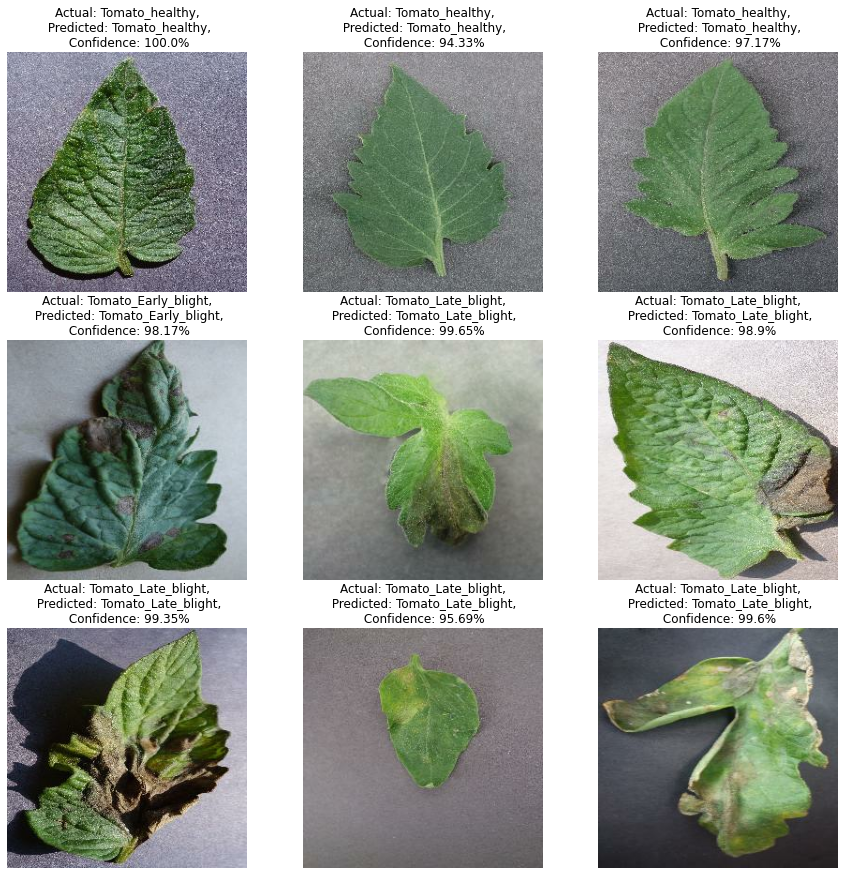

In [ ]:
plt.figure(figsize = (15,15))
for images, labels in test_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3,3, i +1)
    plt.imshow(images[i].numpy().astype("uint8"))

    predicted_class, confidence = predict(model, images[i].numpy())
    actual_class = class_names[labels[i]]

    plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class},\n Confidence: {confidence}%")
    plt.axis("off")
  break

In [ ]:
#Saving the model into h5 file
model.save('predict_Tomato_leaves.h5')